# Screening performance of FGW distance and MACE

This notebook compares the screening performance of FGW distance, MACE single-point energy (MACE-SP), MACE relaxed energy (MACE-relaxed), and random selection for

- KI/NaCl
- GaP/GaAs
- GaN/$\mathrm{Al_{2}O_3}$

For each screening budget, the selected candidates are evaluated using the median relative DFT relaxed energy ($\Delta E_{\mathrm{relaxed}}$). Results from random selection are summarized by the median and interquartile range over 1000 repeated draws. The analysis is performed for both the complete and structure-inequivalent registry sets.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter

# Input files
systems = ["KI_NaCl", "GaP_GaAs", "GaN_Al2O3"]
titles = ["KI/NaCl", "GaP/GaAs", r"GaN/$\mathrm{Al_{2}O_{3}}$"]
full_paths = [f"dft_results/{system}.csv" for system in systems]
unique_paths = [f"dft_results/{system}_unique.csv" for system in systems]
# Column names
fgw_col = "fgw_distance_megn_050"
mace_sp_col = "mace_single_point_energy"
mace_relaxed_col = "mace_relaxed_energy"
energy_col = "dft_relaxed_energy"
screening_methods = {"fgw": fgw_col, "mace_sp": mace_sp_col, "mace_relaxed": mace_relaxed_col}
# Screening parameters
full_budgets = np.arange(1, 16)
unique_budgets = np.arange(1, 6)
n_random_draws = 1000
random_seed = 0
# Figure layout
fig_width = 7.2
fig_height = 3.2
fig_layout = dict(
    left=0.05,
    right=0.95,
    bottom=0.05,
    top=0.95,
    wspace=0.35,
)
# Plotting configuration
method_colors = {
    "fgw": "#2166AC",
    "mace_sp": "#6C6FA3",
    "mace_relaxed": "#8F4F64",
    "random": "#7F7F7F",
}
method_markers = {
    "fgw": "s",
    "mace_sp": "D",
    "mace_relaxed": "v",
    "random": "o",
}
method_zorders = {
    "fgw": 5,
    "mace_sp": 4,
    "mace_relaxed": 3,
    "random": 2,
}
method_labels = {
    "fgw": "FGW",
    "mace_sp": "MACE-SP",
    "mace_relaxed": "MACE-relaxed",
    "random": "Random",
}
band_alpha = 0.2
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
})


## Screening performance analysis


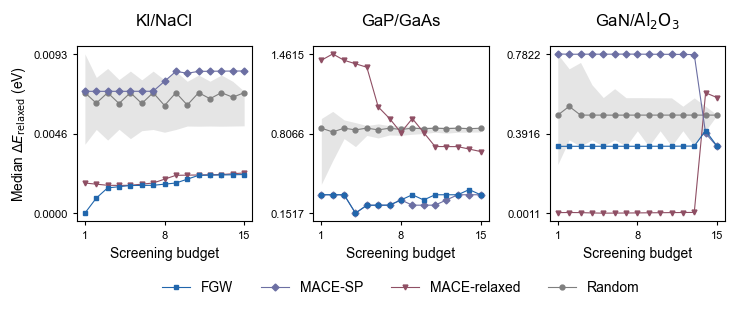

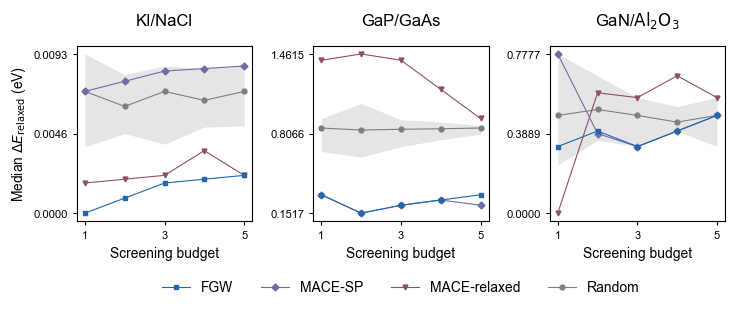

In [2]:
def plot_screening_performance(file_paths, budgets, output_path):
    rng = np.random.default_rng(random_seed)
    results = []

    # Data processing
    for title, path in zip(titles, file_paths):
        df = pd.read_csv(path)
        relative_energies = (df[energy_col]-df[energy_col].min()).to_numpy()
        energy_curves = {}
        # FGW and MACE screening
        for method, score_col in screening_methods.items():
            scores = df[score_col].to_numpy()
            ranked_indices = np.argsort(scores, kind="stable")
            energy_curves[method] = np.array([
                np.median(relative_energies[ranked_indices[:k]])
                for k in budgets
            ])
        # Random screening
        random_energies = np.empty((n_random_draws, len(budgets)))
        for budget_index, k in enumerate(budgets):
            for draw_index in range(n_random_draws):
                selected_indices = rng.choice(len(df), size=k, replace=False)
                random_energies[draw_index, budget_index] = np.median(relative_energies[selected_indices])
        energy_curves["random_q25"] = np.percentile(random_energies, 25, axis=0)
        energy_curves["random_median"] = np.median(random_energies, axis=0)
        energy_curves["random_q75"] = np.percentile(random_energies, 75, axis=0)
        results.append((title, energy_curves))

    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(fig_width, fig_height), sharex=True)
    plt.subplots_adjust(**fig_layout)

    for ax, (title, energy_curves) in zip(axes, results):
        ax.set_title(title, pad=15)
        # Random median curve with interquartile range
        ax.fill_between(
            budgets,
            energy_curves["random_q25"],
            energy_curves["random_q75"],
            color=method_colors["random"],
            alpha=band_alpha,
            linewidth=0,
            zorder=1,
        )
        ax.plot(
            budgets,
            energy_curves["random_median"],
            color=method_colors["random"],
            linestyle="-",
            linewidth=0.8,
            marker=method_markers["random"],
            markersize=3.5,
            zorder=method_zorders["random"],
        )
        # FGW and MACE curves
        for method in screening_methods:
            ax.plot(
                budgets,
                energy_curves[method],
                color=method_colors[method],
                linestyle="-",
                linewidth=0.8,
                marker=method_markers[method],
                markersize=3.5,
                zorder=method_zorders[method],
            )
        # Panel formatting
        x_min = budgets.min()
        x_max = budgets.max()
        x_padding = 0.05 * (x_max - x_min)
        ax.set_xlim(x_min-x_padding, x_max+x_padding)
        ax.set_xticks(np.linspace(x_min, x_max, 3))
        y_max = max(np.max(curve) for curve in energy_curves.values())
        y_min = min(np.min(curve) for curve in energy_curves.values())
        y_padding = 0.05 * (y_max - y_min)
        ax.set_ylim(y_min-y_padding, y_max+y_padding)
        ax.set_yticks(np.linspace(y_min, y_max, 3))
        ax.yaxis.set_major_formatter(FormatStrFormatter("%.4f"))
        ax.tick_params(direction="out", length=3, width=0.8)
        ax.set_box_aspect(1)
        ax.set_xlabel("Screening budget")

    axes[0].set_ylabel(r"Median $\Delta E_{\mathrm{relaxed}}$ (eV)")
    legend_handles = [
        Line2D(
            [0], [0],
            color=method_colors[method],
            linestyle="-",
            linewidth=0.8,
            marker=method_markers[method],
            markersize=3.5,
            label=method_labels[method],
        )
        for method in method_labels
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.08),
        ncol=4,
        frameon=False,
        handlelength=2,
        columnspacing=2,
    )
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

plot_screening_performance(file_paths=full_paths, budgets=full_budgets, output_path="screening_performance.pdf")
plot_screening_performance(file_paths=unique_paths, budgets=unique_budgets, output_path="screening_performance_unique.pdf")
